# 4c_SIM_MODEL — Similarity Configuration & Artefact Export

Configures the **Similarity (kernel regression)** model using optimised
K and per-feature σ from `sim_best_params.json`. No parametric model
is trained — the reference database IS the model.

| § | Stage | Notes |
|---|---|---|
| 1 | Config & imports | `from lib.similarity import similarity_predict` |
| 2 | Load reference parquet | IHFC_obs.parquet |
| 3 | Load params (K, σ, obs_sel) | From `sim_best_params.json` |
| 4 | Train/test split + scaler | Same seed/fraction as 4a/4b |
| 5 | Predict on test set | numba JIT, `W_t=ones`, `use_sigma_helper=False` |
| 6 | Centre-bias correction spline | Cal-set, consistent with 4a/4b |
| 7 | σ bar chart | Per-feature bandwidth diagnostic |
| 8 | Metrics | R², RMSE, MAE, N_eff, Shannon H |
| 9 | Diagnostic figures | Scatter, residuals, N_eff histogram |
| 10 | Bundle artefacts | `sim_artefacts.pkl` incl. reference DB |

**Outputs**
- `output/models/sim_artefacts.pkl`  (includes `X_tr_ref`, `y_tr_ref`)
- `output/models/sim_metrics.csv`
- `fig/models/sim_*.png`

> **`similarity_predict` call convention** (from `lib/similarity.py`):
> `W_t` = per-**target** weights (pass `np.ones(n_tgt)`). Reference
> weights `w_tr` are not an argument — the reference set is used as-is.
> `S_r` = the 1-D `sigma_arr` (already per-feature); set
> `use_sigma_helper=False` so `prepare_sigma()` is not called again.

> **Spline on cal slice:** All three model notebooks (4a/4b/4c) fit
> the centre-bias correction spline on the held-out calibration slice,
> avoiding the leave-in bias of self-predicting on the full train set.

## 1. Imports & constants

In [1]:
import sys, json, pickle, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.interpolate import PchipInterpolator
from scipy.stats import entropy as scipy_entropy
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
warnings.filterwarnings('ignore')

# ── paths ──────────────────────────────────────────────────────────────────────
local_data = Path('data')
param_dir  = Path('output/sweeps')
model_dir  = Path('output/models')
fig_dir    = Path('fig/models')
model_dir.mkdir(parents=True, exist_ok=True)
fig_dir.mkdir(parents=True, exist_ok=True)

# ── shared constants ───────────────────────────────────────────────────────────
TEST_FRAC       = 0.20
RANDOM_SEED     = 42
TARGET_COL      = 'q'
Q_CLIP_MIN      = 0.0
QUANTILES       = [0.05, 0.25, 0.50, 0.75, 0.95]
QUANTILES_DENSE = np.linspace(0.02, 0.98, 49).tolist()
HIST_BIN_W      = 0.010
CONFORMAL_ALPHA = 0.10
SPLINE_PCTLS    = 200
FIG_DPI         = 150

from config import obs_model, q_clip_max, random_state
print(f'obs_model features : {len(obs_model)}')
print(f'q_clip_max         : {q_clip_max} W/m²')
print(f'Test fraction      : {TEST_FRAC}')


✓ config.py v4.0 | obs_model: 21 | obs_sweep: 22 | obs: 36
obs_model features : 21
q_clip_max         : 0.35 W/m²
Test fraction      : 0.2


## 2. Load reference data

In [2]:
df = pd.read_parquet(local_data / 'IHFC_obs.parquet').copy()
print(f'Raw rows: {len(df)}')

df = df.dropna(subset=obs_model)
print(f'After dropna : {len(df)} rows')

if 'weight' in df.columns:
    w_all = df['weight'].values.astype(np.float32)
    w_all = w_all / w_all.mean()
    print(f'Weights  min={w_all.min():.4f}  max={w_all.max():.4f}  mean={w_all.mean():.4f}')
else:
    w_all = np.ones(len(df), dtype=np.float32)
    print('WARNING: no weight column — using uniform weights')


Raw rows: 30848
After dropna : 30847 rows
Weights  min=0.1123  max=3.5262  mean=1.0000


## 3. Load sweep parameters (K, σ, obs_sel)

In [3]:
from lib.similarity import similarity_predict, prepare_sigma

with open(param_dir / 'sim_best_params.json') as fp:
    PARAMS = json.load(fp)

# obs_sel: exactly the feature list recorded in the sweep JSON (single source of truth)
obs_sel = PARAMS['obs_sel']
assert isinstance(obs_sel, list) and obs_sel, 'obs_sel missing/empty in sweep JSON'



# sanity
print(f'obs_sel ({len(obs_sel)} features) loaded from JSON')


K          = float(PARAMS['SIM_BEST_K'])
SIM_SIGMAS = {f: float(v) for f, v in PARAMS['SIM_SIGMAS'].items()}

# sigma_arr: 1-D per-feature bandwidth (already in StandardScaler-normalised units)
sigma_arr  = np.array([SIM_SIGMAS.get(f, 1.0) for f in obs_sel], dtype=np.float32)

print(f'Loaded sim_best_params.json')
print(f'  features ({len(obs_sel)}): {obs_sel}')
print(f'  K = {K:.4f}')
print(f'  sigma_arr range: [{sigma_arr.min():.3f}, {sigma_arr.max():.3f}]')
print(f'  cv_r2_full = {PARAMS.get("cv_r2_full", "n/a")}')


obs_sel (22 features) loaded from JSON
Loaded sim_best_params.json
  features (22): ['FREE_AIR', 'GEOID', 'BOUGUER', 'REVEAL_P150', 'DEM', 'MOHO', 'REVEAL_S80', 'LITH_RHO', 'CTD', 'MOHO_GRAV', 'EMAG2_LOG', 'REVEAL_S100', 'SI', 'CRUST_RHO', 'REVEAL_S70', 'SEDIMENT', 'REVEAL_VP90VS60', 'REVEAL_VP50VS80', 'REVEAL_S90', 'REVEAL_VP60VS70', 'LAB', 'MAG_SEIS_MOHO']
  K = 16.9546
  sigma_arr range: [0.271, 3.442]
  cv_r2_full = 0.43099249601364137


In [4]:
# Per-feature adaptive floor — tuning owned by the sweep, loaded from sim_best_params.json (3c)
OOD_WORST       = PARAMS['OOD_WORST']
SIGMA_FLOOR_MIN = PARAMS['SIGMA_FLOOR_MIN']

sigma_arr_orig = sigma_arr.copy()   # keep original for comparison
sigma_arr_new  = sigma_arr.copy()

for i, feat in enumerate(obs_sel):
    ood = OOD_WORST.get(feat, 0.0)
    adaptive_floor = sigma_arr_orig[i] / max(1.0 - ood, 0.40)
    sigma_arr_new[i] = max(sigma_arr_orig[i], adaptive_floor, SIGMA_FLOOR_MIN)

sigma_arr = sigma_arr_new.astype(np.float32)
print("Adaptive sigma floors applied:")
for f, s_old, s_new in zip(obs_sel, sigma_arr_orig, sigma_arr):
    tag = ' ← raised' if s_new > s_old + 0.001 else ''
    print(f"  {f:28s}  {s_old:.3f} → {s_new:.3f}{tag}")

Adaptive sigma floors applied:
  FREE_AIR                      1.019 → 1.019
  GEOID                         0.370 → 0.524 ← raised
  BOUGUER                       0.271 → 0.516 ← raised
  REVEAL_P150                   0.463 → 0.500 ← raised
  DEM                           0.628 → 0.906 ← raised
  MOHO                          0.362 → 0.500 ← raised
  REVEAL_S80                    0.316 → 0.500 ← raised
  LITH_RHO                      0.609 → 0.775 ← raised
  CTD                           0.396 → 0.500 ← raised
  MOHO_GRAV                     0.449 → 0.574 ← raised
  EMAG2_LOG                     2.596 → 2.596
  REVEAL_S100                   0.845 → 0.845
  SI                            1.709 → 1.709
  CRUST_RHO                     0.686 → 0.686
  REVEAL_S70                    1.532 → 1.980 ← raised
  SEDIMENT                      3.442 → 3.442
  REVEAL_VP90VS60               2.298 → 3.355 ← raised
  REVEAL_VP50VS80               2.195 → 3.163 ← raised
  REVEAL_S90                    1

## 4. Train/test split & StandardScaler

In [5]:
X_all = df[obs_sel].values.astype(np.float32)
y_all = df[TARGET_COL].values.astype(np.float32)

assert np.isfinite(X_all).all(), 'NaNs in X_all — check obs_sel'
assert np.isfinite(y_all).all(), 'NaNs in y_all'

X_tr_raw, X_te_raw, y_tr, y_te, w_tr, w_te = train_test_split(
    X_all, y_all, w_all, test_size=TEST_FRAC, random_state=RANDOM_SEED)

scaler = StandardScaler().fit(X_tr_raw)
X_tr   = scaler.transform(X_tr_raw).astype(np.float32)
X_te   = scaler.transform(X_te_raw).astype(np.float32)

# Held-out calibration slice (last 10% of train)
cal_frac = float(PARAMS.get('cal_frac', 0.10))
n_cal    = max(int(len(X_tr) * cal_frac), 100)
X_cal, y_cal, w_cal = X_tr[-n_cal:], y_tr[-n_cal:], w_tr[-n_cal:]

print(f'Train  : {len(y_tr):,}    Test : {len(y_te):,}    Cal slice : {n_cal:,}')
print(f'Features used : {len(obs_sel)}')


Train  : 24,677    Test : 6,170    Cal slice : 2,467
Features used : 22


In [6]:
# NOTE: Similarity is non-parametric — ALL train rows serve as the reference
# database. The StandardScaler is fitted on obs_sel (may differ from QRF/GBM
# if sweeps selected different feature sets). sigma_arr is applied INSIDE
# similarity_predict (use_sigma_helper=False: already 1-D, no further prep).
# The calibration slice is used only for spline fitting.
print(f'Reference database (train) : {len(X_tr):,} rows')
print(f'Test set                   : {len(X_te):,} rows')
print(f'Calibration slice          : {len(X_cal):,} rows')


Reference database (train) : 24,677 rows
Test set                   : 6,170 rows
Calibration slice          : 2,467 rows


## 5. Predict on test set

`similarity_predict` from `lib/similarity.py` (numba JIT).
`W_t` = uniform per-target weights (ones). `use_sigma_helper=False`
because `sigma_arr` is already a prepared 1-D array.

In [7]:
# W_t = per-TARGET weights (uniform). Reference weights (w_tr) are NOT an
# argument to similarity_predict — the reference set is used as-is.

SIM_KERNEL = PARAMS.get('SIM_KERNEL', 'rbf')
SIM_WEIGHT_MODE = PARAMS.get('SIM_WEIGHT_MODE', 'shifted_exp')
print(f"Similarity mode: kernel={SIM_KERNEL} | weight_mode={SIM_WEIGHT_MODE}")

print('Predicting on test set (numba JIT — first call compiles cache) ...')
t0 = time.time()

q_te, std_te, N_te, _ = similarity_predict(
    X_ref = X_tr,
    H_ref = y_tr,
    X_tgt = X_te,
    W_t = np.ones(len(X_te), dtype=np.float32),
    S_r = sigma_arr,
    K = float(K),
    W_r = w_tr.astype(np.float32),
    kernel = SIM_KERNEL,
    weight_mode = SIM_WEIGHT_MODE,
    use_sigma_helper = False,
)
print(f' Wall time : {(time.time()-t0)/60:.1f} min')
print(f' NaN fraction : {np.isnan(q_te).mean():.4%}')

sim_q_mean = q_te.astype(np.float32)
sim_q_std = std_te.astype(np.float32)
sim_N = N_te.astype(np.float32)


Similarity mode: kernel=rbf | weight_mode=shifted_exp
Predicting on test set (numba JIT — first call compiles cache) ...
 Wall time : 0.1 min
 NaN fraction : 0.0000%


## 6. Correction spline helpers

In [8]:
from lib.utils import weighted_percentile, build_correction_spline

def apply_spline(vals, spline):
    out    = np.full_like(vals, np.nan, dtype=np.float32)
    ok     = np.isfinite(vals)
    out[ok] = np.clip(spline(vals[ok]).astype(np.float32), Q_CLIP_MIN, q_clip_max)
    return out

print('Spline helpers defined.')


Spline helpers defined.


## 6a. Fit & apply correction spline

PCHIP monotone spline mapping predicted percentiles → observed
percentiles (weighted). Corrects regression-to-the-mean bias.
Fitted on the calibration slice — same as 4a (QRF) and 4b (GBM).

Predicting on calibration slice for spline fitting ...
 Cal prediction wall time: 0.0 min


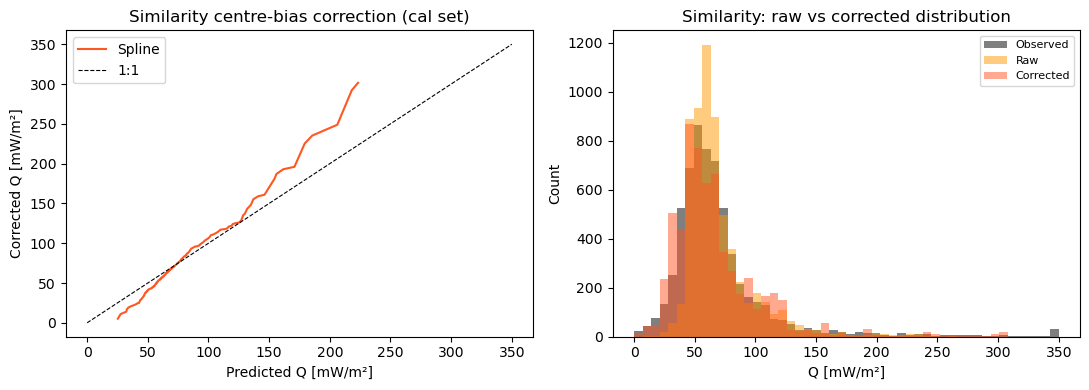

Saved fig/models/sim_correction_spline.png


In [9]:
print('Predicting on calibration slice for spline fitting ...')
t0 = time.time()

q_cal_raw, _, _, _ = similarity_predict(
    X_ref = X_tr,
    H_ref = y_tr,
    X_tgt = X_cal,
    W_t = np.ones(len(X_cal), dtype=np.float32),
    S_r = sigma_arr,
    K = float(K),
    W_r = w_tr.astype(np.float32),
    kernel = SIM_KERNEL,
    weight_mode = SIM_WEIGHT_MODE,
    use_sigma_helper = False,
)
print(f' Cal prediction wall time: {(time.time()-t0)/60:.1f} min')

sim_spline, sim_pred_p, sim_true_p = build_correction_spline(
    q_cal_raw.astype(np.float32), y_cal, w_cal)

sim_q_mean_corr = apply_spline(sim_q_mean, sim_spline)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(sim_pred_p*1e3, sim_true_p*1e3, lw=1.5, color='#FF5722', label='Spline')
axes[0].plot([0, q_clip_max*1e3], [0, q_clip_max*1e3], 'k--', lw=0.8, label='1:1')
axes[0].set_xlabel('Predicted Q [mW/m²]'); axes[0].set_ylabel('Corrected Q [mW/m²]')
axes[0].set_title('Similarity centre-bias correction (cal set)'); axes[0].legend()

bins50 = np.linspace(0, q_clip_max*1e3, 51)
valid = np.isfinite(sim_q_mean_corr)
axes[1].hist(y_te*1e3, bins=bins50, alpha=0.5, label='Observed', color='k')
axes[1].hist(sim_q_mean[valid]*1e3, bins=bins50, alpha=0.5, label='Raw', color='#FF9800')
axes[1].hist(sim_q_mean_corr[valid]*1e3, bins=bins50, alpha=0.5, label='Corrected',color='#FF5722')
axes[1].set_xlabel('Q [mW/m²]'); axes[1].set_ylabel('Count')
axes[1].set_title('Similarity: raw vs corrected distribution'); axes[1].legend(fontsize=8)
fig.tight_layout()
fig.savefig(fig_dir / 'sim_correction_spline.png', dpi=FIG_DPI, bbox_inches='tight')
plt.show(); print(f'Saved {fig_dir}/sim_correction_spline.png')


## 7. Per-feature σ diagnostic

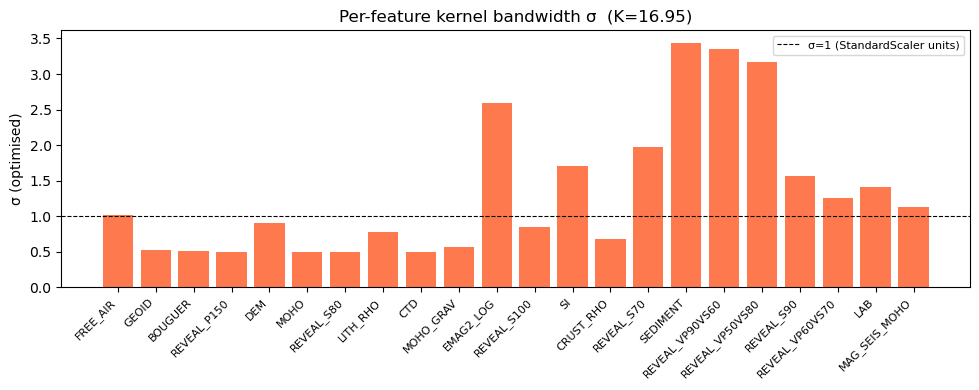

Saved fig/models/sim_sigma_bar.png


In [10]:
fig, ax = plt.subplots(figsize=(max(8, len(obs_sel)*0.45), 4))
x = np.arange(len(obs_sel))
ax.bar(x, sigma_arr, color='#FF5722', alpha=0.8)
ax.axhline(1.0, color='k', lw=0.8, ls='--', label='σ=1 (StandardScaler units)')
ax.set_xticks(x); ax.set_xticklabels(obs_sel, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('σ (optimised)'); ax.set_title(f'Per-feature kernel bandwidth σ  (K={K:.2f})')
ax.legend(fontsize=8); fig.tight_layout()
fig.savefig(fig_dir / 'sim_sigma_bar.png', dpi=FIG_DPI, bbox_inches='tight')
plt.show(); print(f'Saved {fig_dir}/sim_sigma_bar.png')


## 8. Metrics

In [11]:
from lib.utils import empirical_entropy as _empirical_entropy
def empirical_entropy(vals, bin_width=HIST_BIN_W):
    return _empirical_entropy(vals, Q_CLIP_MIN, q_clip_max, bin_width)

def mean_bias(y_true, y_pred):
    valid = np.isfinite(y_pred) & np.isfinite(y_true)
    return float(np.mean(y_pred[valid] - y_true[valid]))

def eval_metrics(y_true, y_pred, y_lo=None, y_hi=None, label=''):
    valid = np.isfinite(y_pred) & np.isfinite(y_true)
    r2    = r2_score(y_true[valid], y_pred[valid])
    rmse  = float(np.sqrt(mean_squared_error(y_true[valid], y_pred[valid])))
    mae   = float(mean_absolute_error(y_true[valid], y_pred[valid]))
    bias  = mean_bias(y_true, y_pred)
    picp  = np.nan
    piw   = np.nan
    if y_lo is not None and y_hi is not None:
        cov  = np.isfinite(y_lo) & np.isfinite(y_hi)
        picp = float(np.mean((y_true[cov] >= y_lo[cov]) & (y_true[cov] <= y_hi[cov])))
        piw  = float(np.mean(y_hi[cov] - y_lo[cov]))
    H = empirical_entropy(y_pred)
    print(f'{label:30s}  R²={r2:.4f}  RMSE={rmse*1e3:.2f} mW/m²  MAE={mae*1e3:.2f}  '
          f'Bias={bias*1e3:.2f}  PICP={picp:.3f}  PI_w={piw*1e3:.1f}  H={H:.3f}')
    return dict(label=label, r2=r2, rmse_mW=rmse*1e3, mae_mW=mae*1e3,
                bias_mW=bias*1e3, picp=picp, pi_width_mW=piw*1e3,
                shannon_H=H, nan_frac=float((~valid).mean()))

print('Metrics helpers defined.')


Metrics helpers defined.


In [12]:
H_obs  = empirical_entropy(y_te)
m_raw  = eval_metrics(y_te, sim_q_mean,      label='SIM raw')
m_corr = eval_metrics(y_te, sim_q_mean_corr, label='SIM corrected')
print(f'Observed entropy : {H_obs:.3f} nat')
print(f'N_eff  median={np.nanmedian(sim_N):.1f}  '
      f'p5={np.nanpercentile(sim_N,5):.1f}  p95={np.nanpercentile(sim_N,95):.1f}')

metrics_df = pd.DataFrame([m_raw, m_corr]).round(4)
metrics_df.to_csv(model_dir / 'sim_metrics.csv', index=False)
print(f'Saved {model_dir}/sim_metrics.csv')


SIM raw                         R²=0.4078  RMSE=34.56 mW/m²  MAE=18.82  Bias=0.19  PICP=nan  PI_w=nan  H=2.146
SIM corrected                   R²=0.3433  RMSE=36.40 mW/m²  MAE=21.00  Bias=-2.93  PICP=nan  PI_w=nan  H=2.453
Observed entropy : 2.463 nat
N_eff  median=0.0  p5=0.0  p95=0.0
Saved output/models/sim_metrics.csv


## 9. Diagnostic figures

In [13]:
from lib.utils import scatter_residuals_fig as _scatter_residuals_fig
def scatter_residuals_fig(rows, suptitle, savepath):
    return _scatter_residuals_fig(rows, suptitle, savepath, Q_CLIP_MIN, q_clip_max, FIG_DPI)

print('Figure helper defined.')


Figure helper defined.


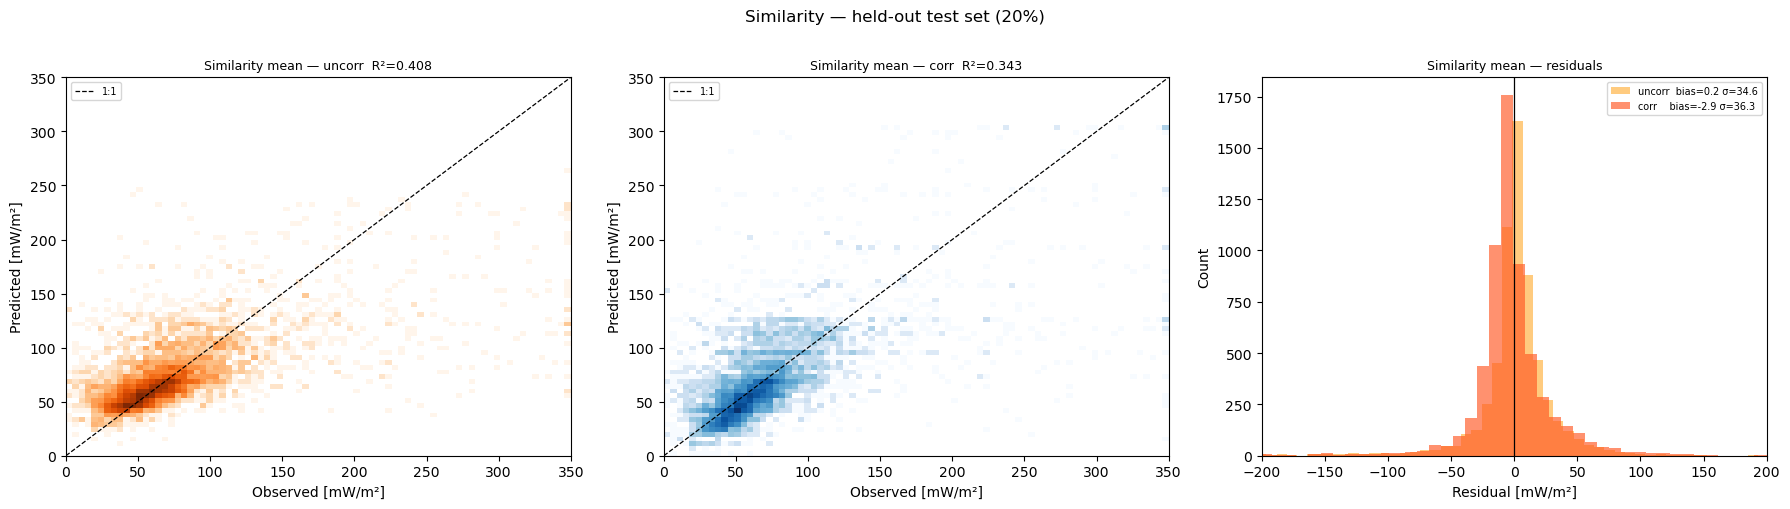

Saved fig/models/sim_scatter_residuals.png


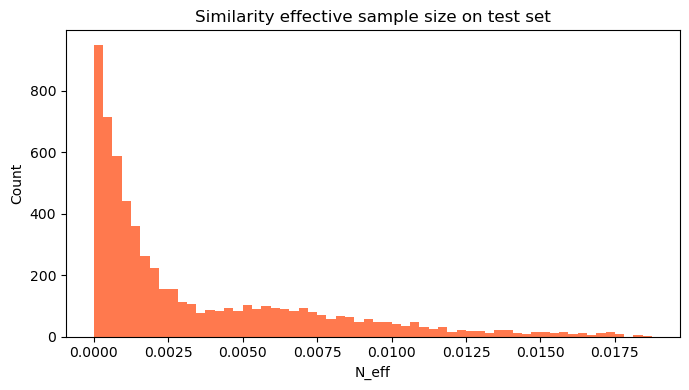

Saved fig/models/sim_neff_hist.png


In [14]:
valid_mask = np.isfinite(sim_q_mean_corr)
scatter_residuals_fig(
    rows=[(y_te[valid_mask], sim_q_mean[valid_mask],
           sim_q_mean_corr[valid_mask], 'Similarity mean', '#FF5722')],
    suptitle='Similarity — held-out test set (20%)',
    savepath=fig_dir / 'sim_scatter_residuals.png',
)

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(sim_N[np.isfinite(sim_N)], bins=60, color='#FF5722', alpha=0.8)
ax.set_xlabel('N_eff'); ax.set_ylabel('Count')
ax.set_title('Similarity effective sample size on test set')
fig.tight_layout()
fig.savefig(fig_dir / 'sim_neff_hist.png', dpi=FIG_DPI, bbox_inches='tight')
plt.show(); print(f'Saved {fig_dir}/sim_neff_hist.png')


## 10. Bundle artefacts for `5c_SIM_TARGETS`

`X_tr_ref`, `y_tr_ref` are the full (scaled) train set — passed
directly as `X_ref` / `H_ref` in `5c`. The usage snippet printed
at runtime shows the exact call signature for `5c`.

In [15]:
# W_t (per-target reference weights) stored for documentation;
# pass W_t=ones when calling similarity_predict from 5_TARGETS.
artefacts = dict(
    model        = 'Similarity',
    obs_sel      = obs_sel,
    scaler       = scaler,
    X_tr_ref     = X_tr,       # StandardScaler-normalised reference features
    y_tr_ref     = y_tr,       # reference heat-flow values
    w_tr_ref     = w_tr,       # reference sample weights (informational)
    sigma_arr    = sigma_arr,  # 1-D per-feature sigmas (use_sigma_helper=False)
    K            = float(K),
    spline       = sim_spline,   # canonical key 'spline'
    Q_CLIP_MIN   = Q_CLIP_MIN,
    q_clip_max   = float(q_clip_max),
    PARAMS       = PARAMS,
)
bundle_path = model_dir / 'sim_artefacts.pkl'
with open(bundle_path, 'wb') as fp:
    pickle.dump(artefacts, fp)
print(f'Bundle saved → {bundle_path}')
print('Keys:', list(artefacts.keys()))
print()
print('Usage in 5c_SIM_TARGETS:')
print('  art = pickle.load(open("output/models/sim_artefacts.pkl", "rb"))')
print('  q, std, N, _ = similarity_predict(')
print('      X_ref=art["X_tr_ref"], H_ref=art["y_tr_ref"],')
print('      X_tgt=X_tgt_scaled, W_t=np.ones(n_tgt, dtype=np.float32),')
print('      S_r=art["sigma_arr"], K=art["K"], use_sigma_helper=False)')


Bundle saved → output/models/sim_artefacts.pkl
Keys: ['model', 'obs_sel', 'scaler', 'X_tr_ref', 'y_tr_ref', 'w_tr_ref', 'sigma_arr', 'K', 'sim_spline', 'Q_CLIP_MIN', 'q_clip_max', 'PARAMS']

Usage in 5c_SIM_TARGETS:
  art = pickle.load(open("output/models/sim_artefacts.pkl", "rb"))
  q, std, N, _ = similarity_predict(
      X_ref=art["X_tr_ref"], H_ref=art["y_tr_ref"],
      X_tgt=X_tgt_scaled, W_t=np.ones(n_tgt, dtype=np.float32),
      S_r=art["sigma_arr"], K=art["K"], use_sigma_helper=False)
